In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

n_nodes = "all"

traj = 1

if traj == 1:
    file_path = "tube_data/tube_test1_22pts_v1.json"
    drop_first_points = 0
    expected_points = 22 - drop_first_points
    output_path = f"n7_traj1_tube_dataset_{expected_points}_pts.npz"
elif traj == 2:
    file_path = "tube_data/tube_test2_16pts_v1.json"
    drop_first_points = 0
    expected_points = 16 - drop_first_points
    output_path = f"n7_traj2_tube_dataset_{expected_points}_pts.npz"
elif traj == 3:
    file_path = "tube_data/tube_test3_16pts_v1.json"
    drop_first_points = 0
    expected_points = 16 - drop_first_points
    output_path = f"n7_traj3_tube_dataset_{expected_points}_pts.npz"
elif traj == 4:
    file_path = "tube_data/tube_test4_30pts_v1.json"
    drop_first_points = 0
    expected_points = 30 - drop_first_points
    output_path = f"n7_traj4_tube_dataset_{expected_points}_pts.npz"
elif traj == 5:
    file_path = "tube_data/tube_test5_30pts_v1.json"
    drop_first_points = 0
    expected_points = 30 - drop_first_points
    output_path = f"n7_traj5_tube_dataset_{expected_points}_pts.npz"
elif traj == 6:
    file_path = "tube_data/tube_test6_23pts_v1.json"
    drop_first_points = 0
    expected_points = 23 - drop_first_points
    output_path = f"n7_traj6_tube_dataset_{expected_points}_pts.npz"
elif traj == 7:
    file_path = "tube_data/tube_test7_23pts_v1.json"
    drop_first_points = 0
    expected_points = 23 - drop_first_points
    output_path = f"n7_traj7_tube_dataset_{expected_points}_pts.npz"
elif traj == 8:
    file_path = "tube_data/tube_test8_29pts_v1.json"
    drop_first_points = 0
    expected_points = 29 - drop_first_points
    output_path = f"n7_traj8_tube_dataset_{expected_points}_pts.npz"

Loaded 22 samples
Persistent markers kept: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_4', 'marker_5', 'marker_6']
Fixed marker used for origin: marker_6
Markers used in state: ['marker_5', 'marker_4', 'marker_3', 'marker_2', 'marker_1']
Final node = marker_0 (no end-effector used in state/BCs)


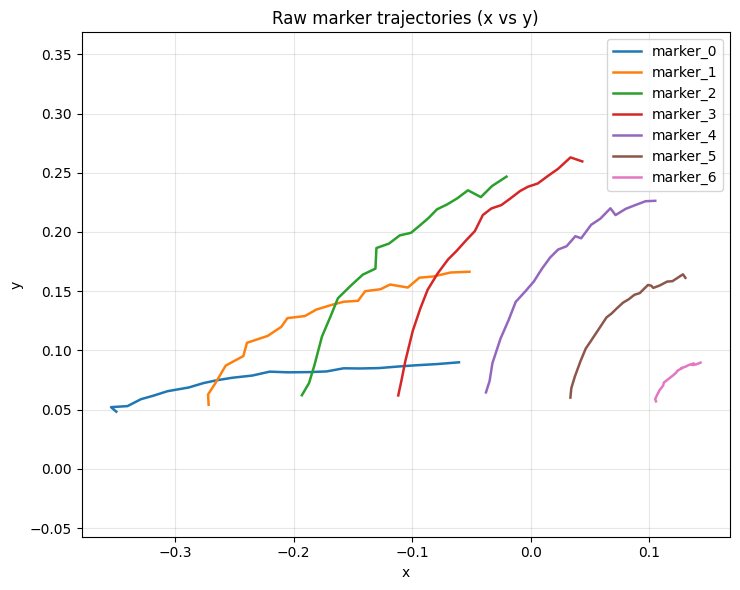

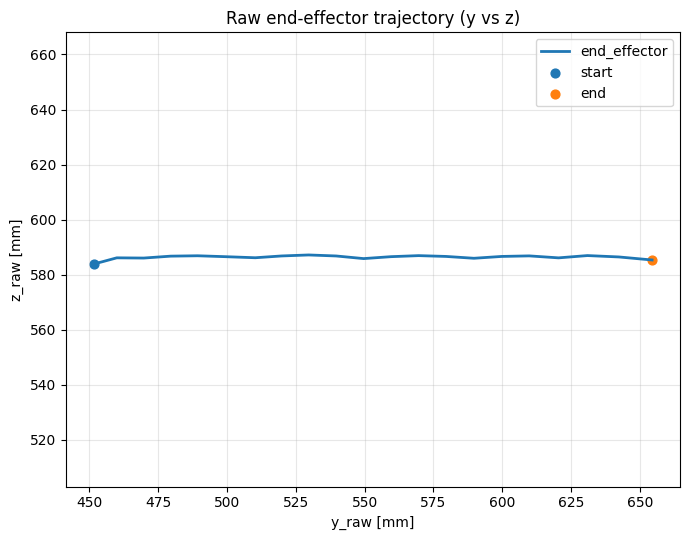

Origin from fixed marker mean:
x0 = 0.12442550457188593
y0 = 0.07964637976138131
z0 = 0.6463416635653098


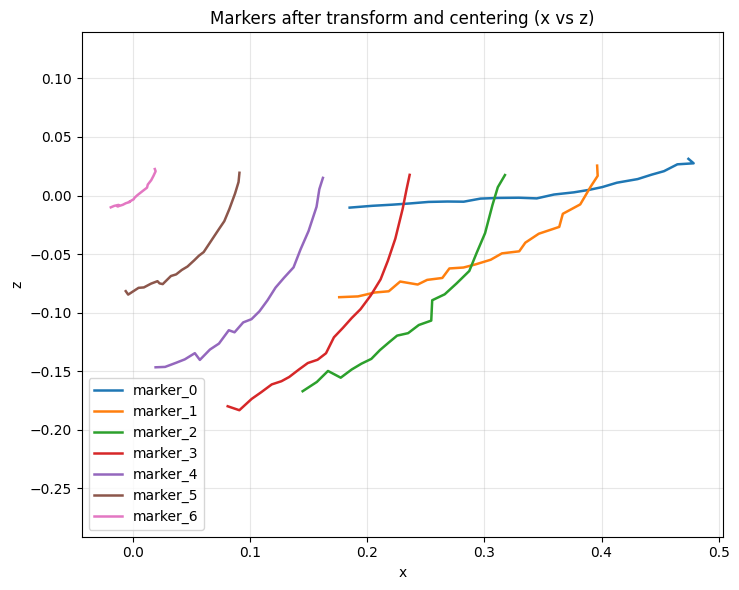

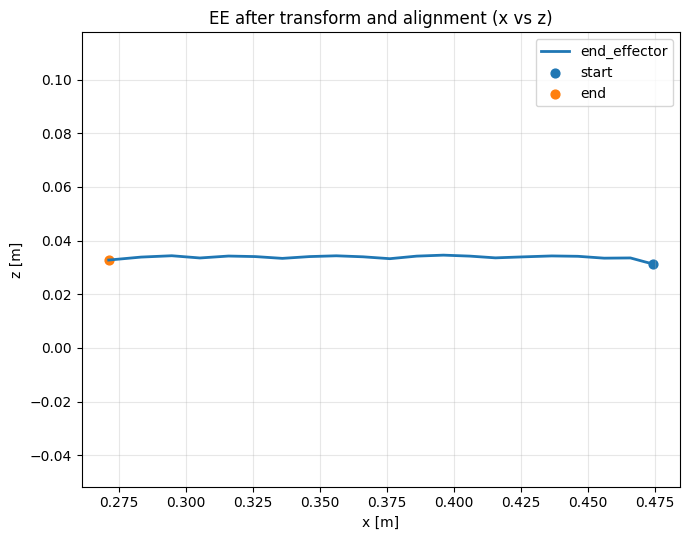

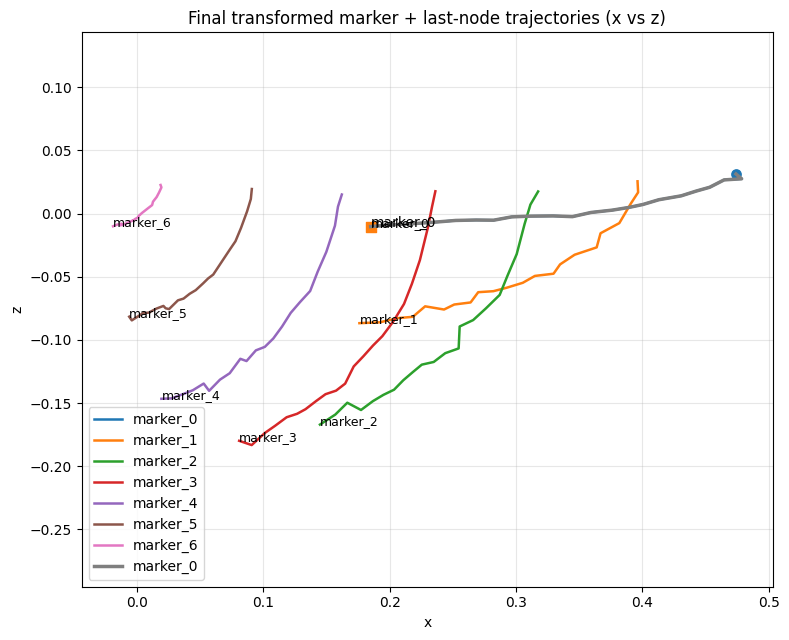

Removing NaNs: kept 22/22 timesteps
target_n_nodes: 7
use_ee_as_last_node: False
prepend_clamped_node_flag: False
append_right_ghost_clamp_flag: False
min_marker_presence_ratio: 0.8
qs shape: (1, 22, 27)
xb shape: (1, 22, 12)
idx_b: [ 0  1  2  3  7 11 15 19 23 24 25 26]
lambdas shape: (1, 22)


In [3]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=drop_first_points, n_nodes=n_nodes, use_ee_as_last_node=False, prepend_clamped_node_flag=False, append_right_ghost_clamp_flag=False)

In [4]:
# from extract_data_strip import extract_directbc_dataset, plot_qs_snapshots
# qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_point=False, n_nodes=n_nodes, use_ee_as_last_node=False, prepend_clamped_node_flag=False, append_right_ghost_clamp_flag=False)

In [5]:
print(qs[0,0,:])

[0.         0.         0.         0.         0.09086155 0.
 0.01942418 0.         0.16212045 0.         0.0150601  0.
 0.23617013 0.         0.01763751 0.         0.31752742 0.
 0.01747101 0.         0.39623164 0.         0.02552404 0.
 0.47417399 0.         0.03131223]


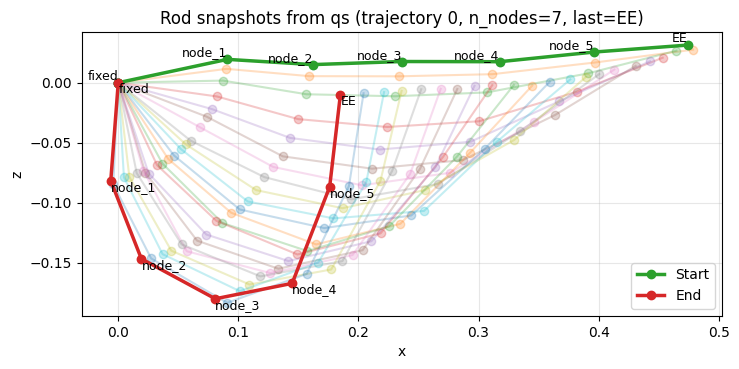

In [6]:
plot_qs_snapshots(qs, every_step=1)

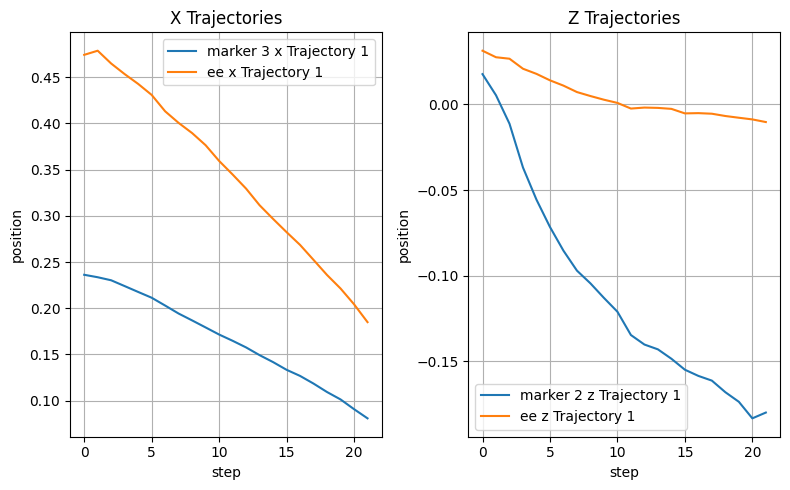

In [7]:
import matplotlib.pyplot as plt
# plot end effector and center marker trajectories for x and z directions

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 12], label=f"marker 3 x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 14], label=f"marker 2 z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()